In [22]:
import requests 
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import os
import folium
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv("OPEN_WEATHER_API_KEY")

In [10]:
city = "Pune"
url = "https://api.openweathermap.org/data/2.5/forecast"
params = {
    "q" : city,
    "appid": API_KEY,
    "units": "metric"
}

response = requests.get(url, params = params)
data = response.json()
print(data)

{'cod': '200', 'message': 0, 'cnt': 40, 'list': [{'dt': 1787086800, 'main': {'temp': 24.01, 'feels_like': 24.4, 'temp_min': 24.01, 'temp_max': 24.09, 'pressure': 1010, 'sea_level': 1010, 'grnd_level': 937, 'humidity': 74, 'temp_kf': -0.08, 'dew_point': 19.09}, 'weather': [{'id': 803, 'main': 'Clouds', 'description': 'broken clouds', 'icon': '04n'}], 'clouds': {'all': 78}, 'wind': {'speed': 3.58, 'deg': 268, 'gust': 10.28}, 'visibility': 10000, 'pop': 0.12, 'sys': {'pod': 'n'}, 'dt_txt': '2026-08-18 21:00:00'}, {'dt': 1787097600, 'main': {'temp': 23.46, 'feels_like': 24.08, 'temp_min': 23.21, 'temp_max': 23.46, 'pressure': 1010, 'sea_level': 1010, 'grnd_level': 937, 'humidity': 85, 'temp_kf': 0.25, 'dew_point': 20.79}, 'weather': [{'id': 804, 'main': 'Clouds', 'description': 'overcast clouds', 'icon': '04n'}], 'clouds': {'all': 88}, 'wind': {'speed': 2.87, 'deg': 257, 'gust': 5.63}, 'visibility': 10000, 'pop': 0.12, 'sys': {'pod': 'n'}, 'dt_txt': '2026-08-19 00:00:00'}, {'dt': 178710840

In [14]:

# 3. Extract weather attributes
records = []
for record in data['list']:
    weather = {
        "Date" : record['dt_txt'],
        "Temperature" : record["main"]["temp"],
        "Humidity": record["main"]["humidity"],
        "Wind_Speed" : record["wind"]["speed"],
        "Rain": record.get("rain", {}).get("3h", 0)

    }
    records.append(weather)

df = pd.DataFrame(records)

print("\nWeather Data:")
print(df.head())

print("\nShape:", df.shape)


Weather Data:
                  Date  Temperature  Humidity  Wind_Speed  Rain
0  2026-08-18 21:00:00        24.01        74        3.58  0.00
1  2026-08-19 00:00:00        23.46        85        2.87  0.00
2  2026-08-19 03:00:00        25.43        81        4.48  0.00
3  2026-08-19 06:00:00        25.41        74        5.84  0.00
4  2026-08-19 09:00:00        28.81        72        6.46  0.21

Shape: (40, 5)


In [16]:
df.drop_duplicates(inplace=True)
df.fillna(0, inplace=True)

# Convert date
df["Date"] = pd.to_datetime(df["Date"])
print(df.head())

                 Date  Temperature  Humidity  Wind_Speed  Rain
0 2026-08-18 21:00:00        24.01        74        3.58  0.00
1 2026-08-19 00:00:00        23.46        85        2.87  0.00
2 2026-08-19 03:00:00        25.43        81        4.48  0.00
3 2026-08-19 06:00:00        25.41        74        5.84  0.00
4 2026-08-19 09:00:00        28.81        72        6.46  0.21


In [17]:
print("\nAverage Temperature:",
      df["Temperature"].mean())

print("Maximum Temperature:",
      df["Temperature"].max())

print("Minimum Temperature:",
      df["Temperature"].min())

print("Average Humidity:",
      df["Humidity"].mean())

print("Total Rain:",
      df["Rain"].sum())

# Daily aggregation
daily = df.groupby(
    df["Date"].dt.date
).agg({
    "Temperature": "mean",
    "Humidity": "mean",
    "Wind_Speed": "mean",
    "Rain": "sum"
})

print("\nDaily Weather Summary:")
print(daily)


Average Temperature: 24.7355
Maximum Temperature: 29.27
Minimum Temperature: 22.61
Average Humidity: 80.225
Total Rain: 2.3400000000000003

Daily Weather Summary:
            Temperature   Humidity  Wind_Speed  Rain
Date                                                
2026-08-18     24.01000  74.000000    3.580000  0.00
2026-08-19     25.24625  81.125000    4.770000  0.42
2026-08-20     24.96250  80.500000    5.751250  0.65
2026-08-21     24.41625  80.125000    5.651250  0.26
2026-08-22     24.52625  79.750000    5.196250  0.48
2026-08-23     24.60000  80.428571    4.938571  0.53


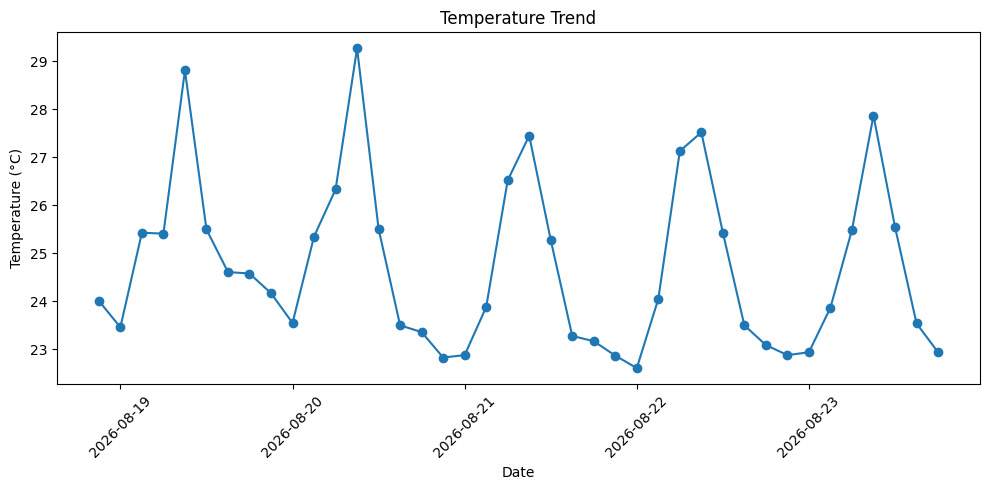

In [18]:
# Temperature trend
plt.figure(figsize=(10, 5))
plt.plot(
    df["Date"],
    df["Temperature"],
    marker="o"
)
plt.title("Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

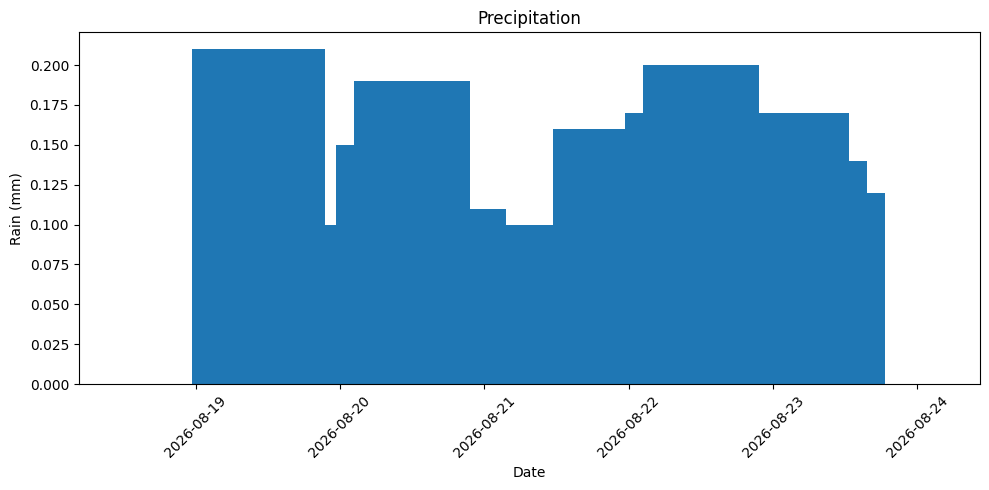

In [19]:
# Rainfall
plt.figure(figsize=(10, 5))
plt.bar(
    df["Date"],
    df["Rain"]
)
plt.title("Precipitation")
plt.xlabel("Date")
plt.ylabel("Rain (mm)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


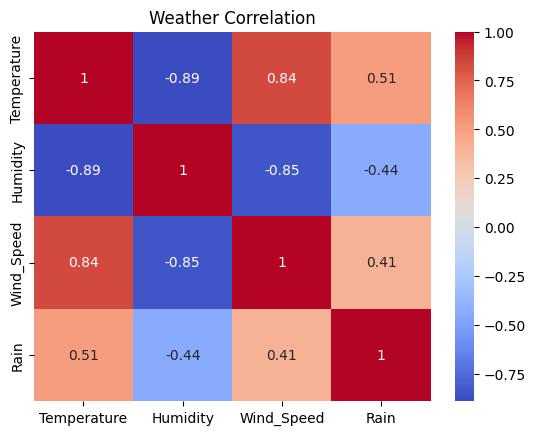

In [20]:
# Correlation heatmap
corr = df[
    ["Temperature", "Humidity",
     "Wind_Speed", "Rain"]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Weather Correlation")
plt.show()

In [23]:
# Geographical map
lat = data["city"]["coord"]["lat"]
lon = data["city"]["coord"]["lon"]

m = folium.Map(
    location=[lat, lon],
    zoom_start=10
)

folium.Marker(
    [lat, lon],
    popup=city
).add_to(m)

m.save("weather_map.html")

print("\nMap saved as weather_map.html")


Map saved as weather_map.html
